# SVM - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

Margin geometry without the optimization lecture: what "widest street" means,
who the support vectors are, and how C/gamma reshape the boundary. Real
penguins data throughout.

### What you'll learn
- Hyperplane, margins and support vectors - drawn, not derived
- The soft-margin objective in plain words
- C and gamma intuition via boundary sweeps
- Why kernels bend straight streets into curves

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins").dropna()
except Exception as e:
    print("offline?", e); raise

easy = pen[pen.species.isin(["Gentoo", "Adelie"])]
X = easy[["bill_length_mm", "bill_depth_mm"]].values
y = (easy.species == "Gentoo").astype(int).values * 2 - 1     # {-1, +1}

### 1. Anatomy of the street

Decision rule: $\hat y=\text{sign}(w^Tx+b)$.
Training chooses $(w,b)$ maximizing margin width $= \frac{2}{\lVert w\rVert}$,
subject to every point satisfying $y_i(w^Tx_i+b)\ge1$.
Points with $y_i(w^Tx_i+b)=1$ EXACTLY sit on the curbs - the support vectors.

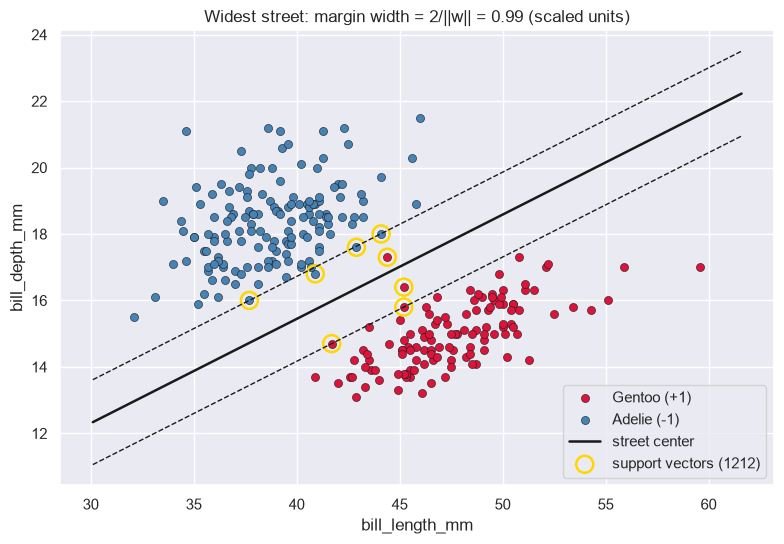

In [2]:
model = Pipeline([("sc", StandardScaler()),
                  ("svm", SVC(kernel="linear", C=1))]).fit(X, y)
w = model.named_steps["svm"].coef_[0]
b = model.named_steps["svm"].intercept_[0]
sv_mask = model.named_steps["svm"].support_

sc_mean, sc_scale = model.named_steps["sc"].mean_, model.named_steps["sc"].scale_
w_orig = w / sc_scale
b_orig = b - (w / sc_scale) @ sc_mean

xs = np.linspace(X[:, 0].min()-2, X[:, 0].max()+2, 200)
margin_w = 2 / np.linalg.norm(w)

plt.figure(figsize=(8, 5.6))
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c="crimson",
            label="Gentoo (+1)", edgecolor="k", lw=.4, s=34)
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], c="steelblue",
            label="Adelie (-1)", edgecolor="k", lw=.4, s=34)
plt.plot(xs, -(b_orig + w_orig[0]*xs)/w_orig[1], "k-", lw=1.8, label="street center")
plt.plot(xs, -(b_orig - 1 + w_orig[0]*xs)/w_orig[1], "k--", lw=1)
plt.plot(xs, -(b_orig + 1 + w_orig[0]*xs)/w_orig[1], "k--", lw=1)
plt.scatter(X[sv_mask][:, 0], X[sv_mask][:, 1], s=150,
            facecolors="none", edgecolors="gold", lw=1.8,
            label=f"support vectors ({sv_mask.sum()})")
plt.xlabel("bill_length_mm"); plt.ylabel("bill_depth_mm")
plt.title(f"Widest street: margin width = 2/||w|| = {margin_w:.2f} (scaled units)")
plt.legend(); plt.tight_layout(); plt.show()

### 2. Soft margin - C prices the rule-breakers

$$\min \frac{1}{2}\lVert w\rVert^2 + C\underbrace{\sum_i \xi_i}_{\text{violations}}$$

Small C: violations cheap → fat tolerant street. Large C: violations expensive →
narrow contorted street hugging every point.

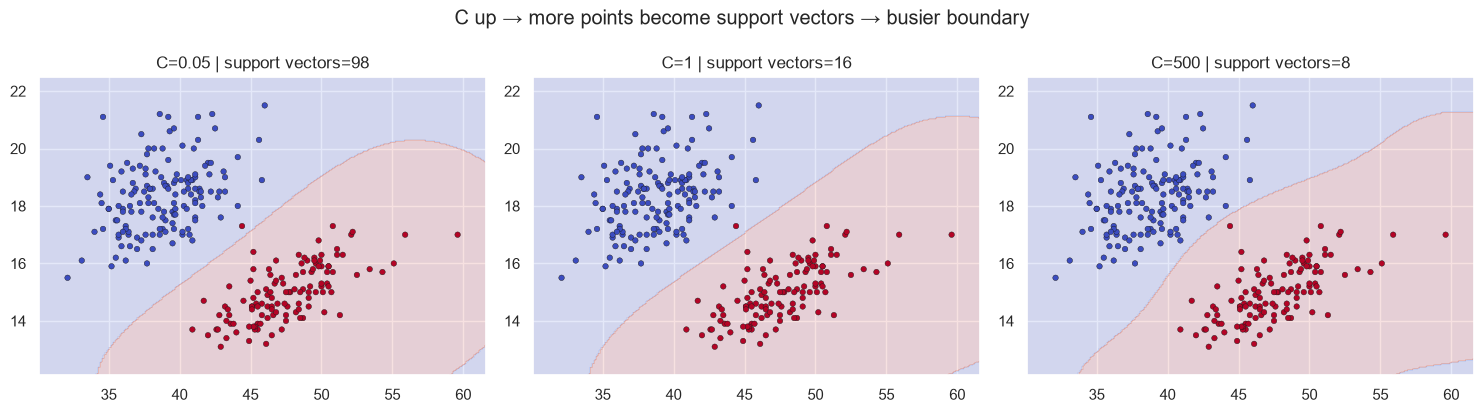

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, C_val in zip(axes, [0.05, 1, 500]):
    m = Pipeline([("sc", StandardScaler()), ("svm", SVC(C=C_val))]).fit(X, y)
    zz = m.decision_function(np.c_[Gxx.ravel(), Gyy.ravel()]).reshape(Gxx.shape) \
        if False else None
    gx = np.linspace(X[:, 0].min()-2, X[:, 0].max()+2, 240)
    gy = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 240)
    Gxx_, Gyy_ = np.meshgrid(gx, gy)
    zz = m.decision_function(np.c_[Gxx_.ravel(), Gyy_.ravel()]).reshape(Gxx_.shape)
    ax.contourf(Gxx_, Gyy_, np.sign(zz), alpha=.15, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=16, edgecolor="k", lw=.3)
    n_sv = m.named_steps["svm"].support_.shape[0]
    ax.set_title(f"C={C_val} | support vectors={n_sv}")
plt.suptitle("C up → more points become support vectors → busier boundary")
plt.tight_layout(); plt.show()

### 3. Kernels - bending space instead of engineering features

RBF similarity between two points:
$$K(x_i,x_j)=\exp(-\gamma\lVert x_i-x_j\rVert^2)$$

gamma small ⇒ gentle global waves · gamma large ⇒ tight local islands.

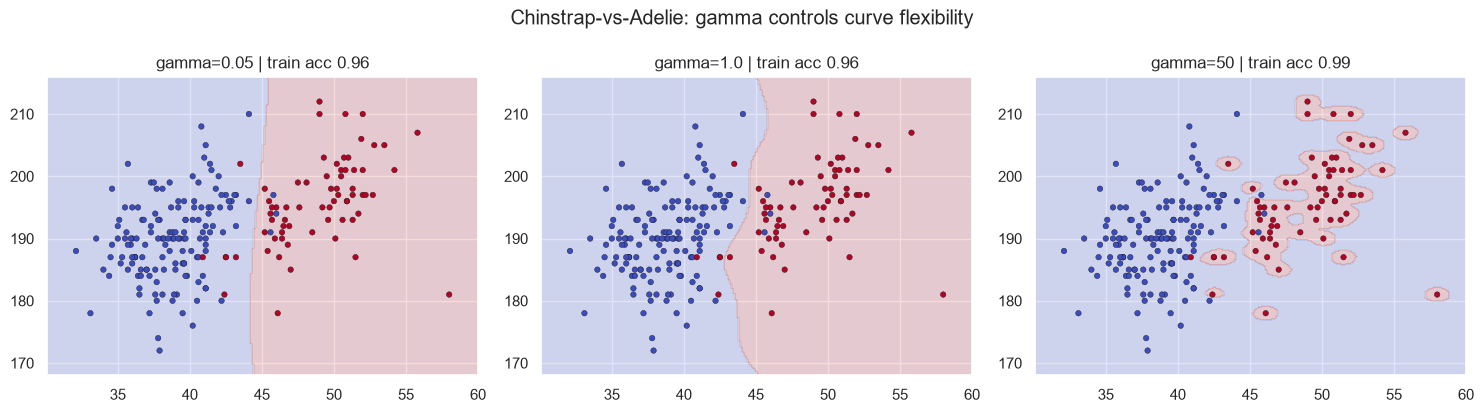

In [4]:
duel = pen[pen.species != "Gentoo"]
Xd = duel[["bill_length_mm", "flipper_length_mm"]].values
yd = (duel.species == "Chinstrap").astype(int).values * 2 - 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, g in zip(axes, [0.05, 1.0, 50]):
    m = Pipeline([("sc", StandardScaler()), ("svm", SVC(gamma=g))]).fit(Xd, yd)
    gx = np.linspace(Xd[:, 0].min()-2, Xd[:, 0].max()+2, 240)
    gy = np.linspace(Xd[:, 1].min()-4, Xd[:, 1].max()+4, 240)
    Gxx_, Gyy_ = np.meshgrid(gx, gy)
    zz = m.predict(np.c_[Gxx_.ravel(), Gyy_.ravel()]).reshape(Gxx_.shape)
    ax.contourf(Gxx_, Gyy_, zz, alpha=.18, cmap="coolwarm")
    ax.scatter(Xd[:, 0], Xd[:, 1], c=yd, cmap="coolwarm", s=16,
               edgecolor="k", lw=.3)
    acc = m.score(Xd, yd)
    ax.set_title(f"gamma={g} | train acc {acc:.2f}")
plt.suptitle("Chinstrap-vs-Adelie: gamma controls curve flexibility")
plt.tight_layout(); plt.show()

### Summary & key takeaways

- Boundary = widest gap; only curb-riders (support vectors) define it.
- C balances street width against violations - the overfit/underfit dial.
- Kernels (RBF/poly) create curved boundaries via point similarities.
- gamma tunes curvature reach: too high memorizes, too low goes linear.